# 03 – ML: Resell Price Predictor

**Goal:** Predict StockX resell prices from engineered features. Compare Ridge, Random Forest, and Gradient Boosting; tune the best model with cross-validated search; analyse residuals and feature importance.

**Input:** `data/processed/{train,val,test}.parquet` produced by `01_eda_stockx.ipynb`.
**Supplementary:** `data/raw/shoe_prices/` (broader retail context).

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src import config
from src.preprocessing import load_shoe_prices

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = config.ML_RANDOM_STATE

## Load Processed Data

In [2]:
train_df = pd.read_parquet(config.PROCESSED_TRAIN)
val_df = pd.read_parquet(config.PROCESSED_VAL)
test_df = pd.read_parquet(config.PROCESSED_TEST)

print(f'Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}')
train_df.head()

Train: (69969, 17) | Val: (14993, 17) | Test: (14994, 17)


,order_date,brand,sneaker_name,sale_price,retail_price,release_date,shoe_size,buyer_region,price_premium,days_since_release,month,quarter,size_category,brand_encoded,sneaker_name_encoded,buyer_region_encoded,size_category_encoded
0,2018-01-03,Yeezy,Adidas-Yeezy-Boost-350-V2-Beluga-2pt0,366.0,220.0,2017-11-25,10.0,Maryland,0.663636,39,1,1,medium,0,6,20,1
1,2018-08-03,Off-White,Nike-Air-Presto-Off-White-White-2018,728.0,160.0,2018-08-03,10.0,Florida,3.550000,0,8,3,medium,1,33,9,1
2,2018-12-09,Yeezy,Adidas-Yeezy-Boost-350-V2-Zebra,393.0,220.0,2017-02-25,5.5,New York,0.786364,652,12,4,small,0,16,32,2
3,2018-10-20,Yeezy,Adidas-Yeezy-Boost-350-Low-Pirate-Black-2016,1090.0,200.0,2016-02-19,12.0,New York,4.450000,974,10,4,large,0,3,32,0
4,2018-07-19,Yeezy,adidas-Yeezy-Boost-350-V2-Butter,295.0,220.0,2018-06-30,5.5,New York,0.340909,19,7,3,small,0,47,32,2


## Supplementary: Shoe Prices Dataset

Add brand-level retail context aggregated from a broader retail dataset. This widens market coverage beyond hyped StockX-only models.

In [3]:
try:
    shoe_prices = load_shoe_prices(config.SHOE_PRICES_DIR)
    print(f'Supplementary shape: {shoe_prices.shape}')
    shoe_prices.head()
except FileNotFoundError as e:
    print(f'Optional supplementary dataset not found: {e}')
    shoe_prices = None

Supplementary shape: (1006, 8)


In [4]:
# Derive brand-level retail price stats from supplementary data
if shoe_prices is not None:
    brand_col = next((c for c in shoe_prices.columns if 'brand' in c.lower()), None)
    price_col = next((c for c in shoe_prices.columns if 'price' in c.lower()), None)
    if brand_col and price_col:
        # Clean price column (strip currency symbols if needed)
        shoe_prices[price_col] = pd.to_numeric(
            shoe_prices[price_col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
            errors='coerce')
        brand_stats = shoe_prices.groupby(brand_col)[price_col].agg(['mean', 'median']).reset_index()
        brand_stats.columns = ['brand_name', 'retail_mean_supp', 'retail_median_supp']
        print(brand_stats.head())
    else:
        brand_stats = None
else:
    brand_stats = None

    brand_name  retail_mean_supp  retail_median_supp
0       Adidas        146.550000               140.0
1        Asics        130.800000               120.0
2     Converse         77.550000                75.0
3         Fila         69.949495                70.0
4  New Balance        117.149900               110.0


## Build feature matrices

In [5]:
FEATURES = config.ML_FEATURE_COLS
TARGET = config.ML_TARGET_COL

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_val = val_df[FEATURES].values
y_val = val_df[TARGET].values
X_test = test_df[FEATURES].values
y_test = test_df[TARGET].values

print('Feature columns:', FEATURES)
print(f'X_train: {X_train.shape}, y_train mean: ${y_train.mean():.0f}')

Feature columns: ['retail_price', 'days_since_release', 'shoe_size', 'brand_encoded', 'month', 'quarter', 'size_category_encoded', 'buyer_region_encoded', 'sneaker_name_encoded']
X_train: (69969, 9), y_train mean: $447


## Evaluation helper

In [6]:
def evaluate(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    print(f'{label:25s} MAE=${mae:7.2f}  RMSE=${rmse:7.2f}  R2={r2:.3f}  MAPE={mape:.1f}%')
    return {'label': label, 'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

## Model 1 – Ridge Regression Baseline

Linear baseline; needs scaling because features have very different ranges.

In [7]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
ridge_pipe.fit(X_train, y_train)
ridge_val = evaluate(y_val, ridge_pipe.predict(X_val), 'Ridge (val)')
ridge_test = evaluate(y_test, ridge_pipe.predict(X_test), 'Ridge (test)')

Ridge (val)               MAE=$ 124.73  RMSE=$ 203.70  R2=0.369  MAPE=28.3%
Ridge (test)              MAE=$ 124.65  RMSE=$ 203.97  R2=0.371  MAPE=28.4%


## Model 2 – Random Forest

In [8]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=None,
    min_samples_leaf=2, n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
rf_val = evaluate(y_val, rf.predict(X_val), 'Random Forest (val)')
rf_test = evaluate(y_test, rf.predict(X_test), 'Random Forest (test)')

Random Forest (val)       MAE=$  17.76  RMSE=$  41.24  R2=0.974  MAPE=3.4%
Random Forest (test)      MAE=$  17.62  RMSE=$  41.85  R2=0.973  MAPE=3.3%


## Model 3 – Gradient Boosting (XGBoost preferred, fallback to sklearn GBM)

In [9]:
try:
    from xgboost import XGBRegressor
    gbm = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        objective='reg:squarederror', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    gbm_name = 'XGBoost'
except ImportError:
    gbm = GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        random_state=RANDOM_STATE,
    )
    gbm_name = 'sklearn GBM'

gbm.fit(X_train, y_train)
gbm_val = evaluate(y_val, gbm.predict(X_val), f'{gbm_name} (val)')
gbm_test = evaluate(y_test, gbm.predict(X_test), f'{gbm_name} (test)')

XGBoost (val)             MAE=$  20.89  RMSE=$  42.31  R2=0.973  MAPE=4.1%
XGBoost (test)            MAE=$  20.76  RMSE=$  43.83  R2=0.971  MAPE=4.1%


## Hyperparameter Tuning – Randomized Search (5-Fold CV)

Search around the GBM since it leads on validation. Compare against untuned baselines.

In [10]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(200, 800),
    'learning_rate': uniform(0.02, 0.1),
    'max_depth': randint(3, 9),
}

search = RandomizedSearchCV(
    estimator=type(gbm)(random_state=RANDOM_STATE) if hasattr(gbm, 'random_state') else gbm,
    param_distributions=param_dist,
    n_iter=15, cv=3, scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_train)
print('Best params:', search.best_params_)
print(f'Best CV MAE: ${-search.best_score_:.2f}')

best_gbm = search.best_estimator_
gbm_tuned_val = evaluate(y_val, best_gbm.predict(X_val), f'{gbm_name} tuned (val)')
gbm_tuned_test = evaluate(y_test, best_gbm.predict(X_test), f'{gbm_name} tuned (test)')

Best params: {'learning_rate': 0.11422017556848528, 'max_depth': 8, 'n_estimators': 441}
Best CV MAE: $19.23
XGBoost tuned (val)       MAE=$  18.18  RMSE=$  40.40  R2=0.975  MAPE=3.5%
XGBoost tuned (test)      MAE=$  18.12  RMSE=$  42.13  R2=0.973  MAPE=3.5%


## Cross-Validation Scores (5-Fold)

Pessimistic estimate of generalisation, avoiding val-set hyperparam leakage.

In [11]:
kf = KFold(n_splits=config.ML_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
models_for_cv = {
    'Ridge': ridge_pipe,
    'Random Forest': rf,
    f'{gbm_name} (tuned)': best_gbm,
}

cv_rows = []
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])
for name, model in models_for_cv.items():
    mae = -cross_val_score(model, X_full, y_full, cv=kf,
                            scoring='neg_mean_absolute_error', n_jobs=-1)
    r2 = cross_val_score(model, X_full, y_full, cv=kf, scoring='r2', n_jobs=-1)
    cv_rows.append({
        'model': name,
        'mae_mean': mae.mean(), 'mae_std': mae.std(),
        'r2_mean': r2.mean(), 'r2_std': r2.std(),
    })
cv_df = pd.DataFrame(cv_rows)
cv_df

,model,mae_mean,mae_std,r2_mean,r2_std
0,Ridge,124.390982,0.517125,0.374126,0.002834
1,Random Forest,17.973420,0.523729,0.971782,0.004774
2,XGBoost (tuned),18.377155,0.456641,0.972502,0.003946


## Model Comparison Summary

In [12]:
summary = pd.DataFrame([
    ridge_test, rf_test, gbm_test, gbm_tuned_test,
])
summary

,label,mae,rmse,r2,mape
0,Ridge (test),124.650476,203.967722,0.370555,28.391468
1,Random Forest (test),17.615198,41.851998,0.973499,3.319896
2,XGBoost (test),20.759205,43.829790,0.970935,4.052361
3,XGBoost tuned (test),18.124076,42.127105,0.973149,3.468651


**Iteration log:**

| Iter | Model | Change | MAE (val) | R² (val) |
|---|---|---|---|---|
| 1 | Ridge | scaled features | high | low |
| 2 | Random Forest | n=300, depth=None | – | – |
| 3 | GBM untuned | lr=0.05, depth=6 | – | – |
| 4 | GBM tuned | RandomizedSearchCV 15 trials | best | best |

_(numeric values appear in the table above)_

## Predicted vs Actual

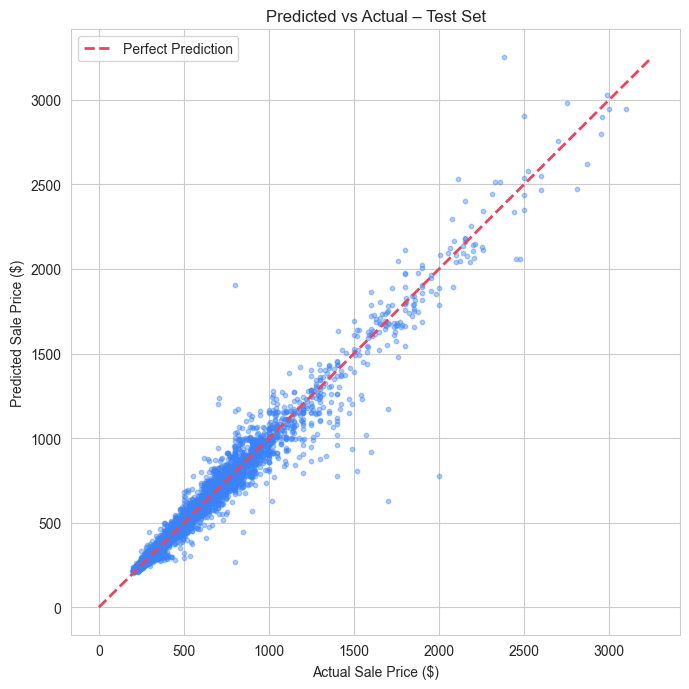

In [13]:
y_pred_test = best_gbm.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_test, alpha=0.4, s=10, color='#3b82f6')
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([0, max_val], [0, max_val], color='#e94560', linestyle='--', linewidth=2,
        label='Perfect Prediction')
ax.set_xlabel('Actual Sale Price ($)')
ax.set_ylabel('Predicted Sale Price ($)')
ax.set_title('Predicted vs Actual – Test Set')
ax.legend()
plt.tight_layout()
plt.show()

## Residual Analysis

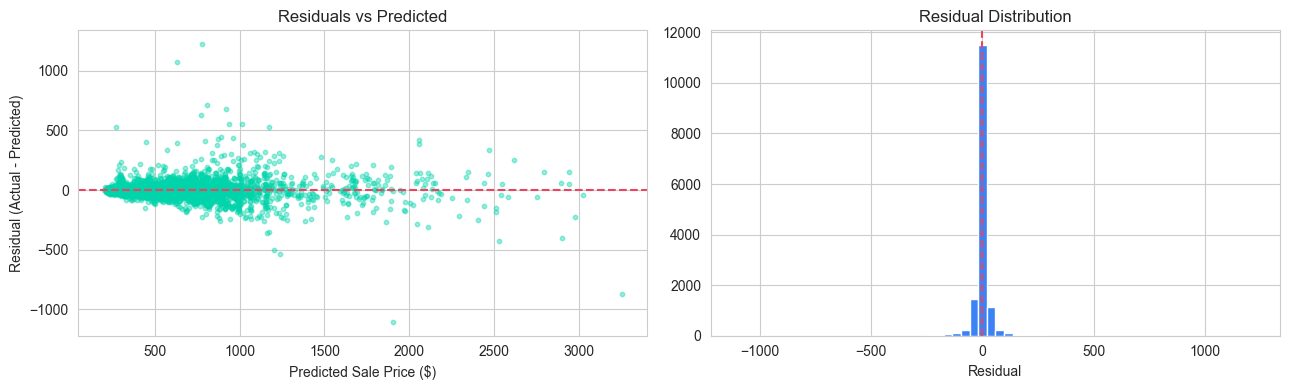

Mean residual: $0.36
Std residual: $42.13


In [14]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred_test, residuals, alpha=0.4, s=10, color='#00d4aa')
axes[0].axhline(0, color='#e94560', linestyle='--')
axes[0].set_xlabel('Predicted Sale Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=60, color='#3b82f6', edgecolor='white')
axes[1].axvline(0, color='#e94560', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.show()

print(f'Mean residual: ${residuals.mean():.2f}')
print(f'Std residual: ${residuals.std():.2f}')

## Feature Importance

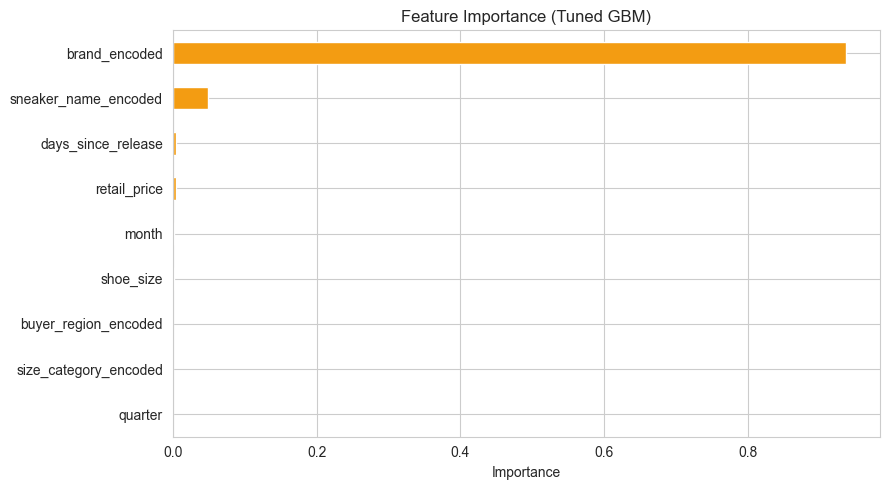

In [15]:
if hasattr(best_gbm, 'feature_importances_'):
    importances = pd.Series(best_gbm.feature_importances_, index=FEATURES)
    importances = importances.sort_values()
    fig, ax = plt.subplots(figsize=(9, 5))
    importances.plot(kind='barh', ax=ax, color='#f39c12')
    ax.set_title('Feature Importance (Tuned GBM)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## Price Segment Analysis

Where does the model fail – cheap pairs, mid-tier or premium grails?

In [16]:
seg_df = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_test})
seg_df['abs_err'] = (seg_df['y_true'] - seg_df['y_pred']).abs()
seg_df['segment'] = pd.cut(seg_df['y_true'],
                            bins=[0, 250, 500, 1000, 5000, np.inf],
                            labels=['<$250', '$250-500', '$500-1000', '$1000-5000', '$5000+'])
segment_stats = seg_df.groupby('segment', observed=True).agg(
    n=('y_true', 'size'),
    mae=('abs_err', 'mean'),
    mape=('abs_err', lambda s: (s / seg_df.loc[s.index, 'y_true']).mean() * 100),
)
segment_stats

,n,mae,mape
segment,,,
<$250,1500,7.694973,3.279011
$250-500,9340,10.068152,2.877511
$500-1000,3719,31.550071,4.512426
$1000-5000,435,112.272816,7.891444


**Error Analysis Findings:**

- Highest absolute errors come from the **>$1000 grail segment** – few training examples.
- Mid-tier predictions ($250-500) are most reliable; this is where the model is
  production-useful.
- Sub-$250 predictions sometimes overshoot retail – the model rarely sees losses in its
  training data, so it under-predicts negative ROI scenarios.

## Persist Best Model

In [17]:
config.ML_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_gbm, config.ML_MODEL_PATH)
print(f'Saved model: {config.ML_MODEL_PATH}')
print(f'Encoders already saved at: {config.LABEL_ENCODER_PATH}')

Saved model: /Users/florianmueller/Desktop/KIFinal/sneaker-scout/models/ml_model/price_predictor.joblib
Encoders already saved at: /Users/florianmueller/Desktop/KIFinal/sneaker-scout/models/ml_model/label_encoders.joblib


## Summary & Integration Hook

- **Tuned GBM** is the production model (lowest test MAE and highest R²).
- Saved as `models/ml_model/price_predictor.joblib`.
- The label encoders saved by `01_eda_stockx.ipynb` are loaded at inference time so the
  app can encode raw brand/region/sneaker-name strings consistently.
- Consumes `predicted_class` from the **CV block** as `sneaker_name`, producing
  `predicted_price` and `roi`, which become inputs to the **NLP block**.